# PatchCore + WideResNet50-2 Multilayer `x224` (Selected Variant)

This notebook is a focused follow-up of notebook `18` for a direct `224x224` preprocessing run.

Upload this notebook and the raw `LSWMD.pkl`, then run all cells. It will:

- prepare the shared `40k / 5k / 5k + 250` report split by default
- optionally build a larger secondary holdout while keeping the original `40k / 5k` train/val fixed
- cache wafer maps directly at `224x224`
- fit the same multilayer `WideResNet50-2` PatchCore model using `layer2 + layer3`
- run the selected `x224` sweep variants
- save repo-compatible summaries under `/output`
- export a reusable selected-variant checkpoint as `best_model.pt`

This keeps the report threshold rule unchanged: threshold = `95th` percentile of validation-normal raw scores.

- save selected-variant embeddings / labels / scores for UMAP
- generate and save histogram + threshold sweep + UMAP plots automatically

In [1]:
RAW_PICKLE = "data/raw/LSWMD.pkl"
OUTPUT_DIR = "artifacts/x224/patchcore-wideresnet50-multilayer-umap"
FALLBACK_METADATA_PATHS = []
USE_EXISTING_ARTIFACTS = True  # set False on Modal to force direct x224 preprocessing rebuild
SECONDARY_HOLDOUT_MODE = False
SECONDARY_TEST_NORMALS = 70_000
SECONDARY_TEST_DEFECTS = 3_500
SAVE_SELECTED_CHECKPOINT = True
SELECTED_CHECKPOINT_NAME = "C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x224\\18A2-patchcore-wideresnet50-multilayer-umap\\topk_mb50k_r005_x224\\best_model.pt"

GENERATE_SELECTED_ARTIFACTS = True
GENERATE_SELECTED_UMAP = True
UMAP_RANDOM_STATE = 42
UMAP_MAX_TRAIN_REFERENCE = 5000
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_MAX_VAL_NORMAL = 5000
UMAP_MAX_TEST_NORMAL = 8000
UMAP_MAX_TEST_ANOMALY = 3500
IMAGE_SIZE = 224
NORMAL_LIMIT = 50_000
TEST_DEFECT_FRACTION = 0.05
BATCH_SIZE = 128
NUM_WORKERS = 0
DEVICE = "auto"
SEED = 42
TEACHER_INPUT_SIZE = 224
TEACHER_LAYERS = ["layer2", "layer3"]
PRETRAINED = True
FREEZE_BACKBONE = True
NORMALIZE_IMAGENET = True
THRESHOLD_QUANTILE = 0.95
QUERY_CHUNK_SIZE = 1024
MEMORY_CHUNK_SIZE = 4096
MIN_MEMORY_IMAGES = 800  # floor on images sampled for memory bank (matches x64 coverage)
SWEEP_VARIANTS = [
    {"name": "topk_mb50k_r010_x224", "memory_bank_size": 600_000, "reduction": "topk_mean", "topk_ratio": 0.10},
    {"name": "topk_mb50k_r005_x224", "memory_bank_size": 600_000, "reduction": "topk_mean", "topk_ratio": 0.05},
]


In [16]:
from __future__ import annotations

import json
import math
import pickle
import random
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas.core.indexes as core_indexes
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, confusion_matrix, precision_score, recall_score, roc_auc_score
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm
from torchvision.models import Wide_ResNet50_2_Weights, wide_resnet50_2

LABEL_NORMAL = "none"
LABEL_DEFECT = "pattern"

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "artifacts").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.evaluation import export_reference_umap_bundle

def resolve_project_path(path_str: str) -> Path:
    path = Path(path_str)
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def resolve_device(device_name: str) -> torch.device:
    return torch.device("cuda" if device_name == "auto" and torch.cuda.is_available() else device_name)

def read_legacy_pickle(path: Path) -> pd.DataFrame:
    sys.modules["pandas.indexes"] = core_indexes
    with path.open("rb") as handle: return pickle.load(handle, encoding="latin1")

def unwrap_legacy_value(value: Any) -> str:
    if value is None: return ""
    if hasattr(value, "size") and getattr(value, "size") == 0: return ""
    if hasattr(value, "tolist"): value = value.tolist()
    while isinstance(value, list) and len(value) == 1: value = value[0]
    return str(value).strip()

def normalize_map(wafer_map: np.ndarray, image_size: int) -> np.ndarray:
    wafer_map = np.asarray(wafer_map, dtype=np.float32) / 2.0
    tensor = torch.from_numpy(wafer_map).unsqueeze(0).unsqueeze(0)
    return F.interpolate(tensor, size=(image_size, image_size), mode="bilinear", align_corners=False).squeeze(0).squeeze(0).numpy()

def infer_label_from_row(row: pd.Series) -> str | None:
    failure = unwrap_legacy_value(row.get("failureType", "")).lower()
    if failure == "none": return LABEL_NORMAL
    if failure: return LABEL_DEFECT
    return None

def split_normals(normal_df: pd.DataFrame, seed: int) -> pd.DataFrame:
    shuffled = normal_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(shuffled); train_end = int(0.8 * n); val_end = int(0.9 * n)
    shuffled.loc[: train_end - 1, "split"] = "train"; shuffled.loc[train_end: val_end - 1, "split"] = "val"; shuffled.loc[val_end:, "split"] = "test"
    return shuffled

def format_count_slug(count: int) -> str:
    if count >= 1000 and count % 1000 == 0: return f"{count // 1000}k"
    if count >= 1000 and count % 100 == 0: return f"{count / 1000:.1f}".replace(".", "p") + "k"
    return str(count)

def build_holdout_suffix(secondary_test_normals: int, secondary_test_defects: int) -> str:
    return f"holdout{format_count_slug(secondary_test_normals)}_{format_count_slug(secondary_test_defects)}"

def build_metadata_filename(use_secondary_holdout: bool, secondary_test_normals: int, secondary_test_defects: int) -> str:
    if not use_secondary_holdout: return "metadata_50k_5pct.csv"
    return f"metadata_50k_5pct_{build_holdout_suffix(secondary_test_normals, secondary_test_defects)}.csv"

def build_arrays_dir_name(use_secondary_holdout: bool, secondary_test_normals: int, secondary_test_defects: int) -> str:
    if not use_secondary_holdout: return "arrays"
    return f"arrays_{build_holdout_suffix(secondary_test_normals, secondary_test_defects)}"

def sample_test_defects(defect_df: pd.DataFrame, normal_df: pd.DataFrame, fraction: float, seed: int) -> pd.DataFrame:
    requested = max(1, int(round(int((normal_df["split"] == "test").sum()) * fraction)))
    sampled = defect_df.sample(n=min(requested, len(defect_df)), random_state=seed).copy(); sampled["split"] = "test"; return sampled

def build_secondary_holdout_export_df(df: pd.DataFrame, normal_limit: int, test_defect_fraction: float, secondary_test_normals: int, secondary_test_defects: int, seed: int) -> pd.DataFrame:
    normal_df = df[df["label"] == LABEL_NORMAL].copy(); defect_df = df[df["label"] == LABEL_DEFECT].copy()
    base_normals = normal_df.sample(n=min(normal_limit, len(normal_df)), random_state=seed).copy(); base_normals = split_normals(base_normals, seed)
    base_defects = sample_test_defects(defect_df, base_normals, test_defect_fraction, seed)
    used_raw_indices = set(base_normals["raw_index"].astype(int).tolist()); used_raw_indices.update(base_defects["raw_index"].astype(int).tolist())
    normal_pool = normal_df[~normal_df["raw_index"].isin(used_raw_indices)].copy(); defect_pool = defect_df[~defect_df["raw_index"].isin(used_raw_indices)].copy()
    if secondary_test_normals > len(normal_pool): raise ValueError(f"Requested {secondary_test_normals} secondary-holdout normals, but only {len(normal_pool)} are available.")
    if secondary_test_defects > len(defect_pool): raise ValueError(f"Requested {secondary_test_defects} secondary-holdout defects, but only {len(defect_pool)} are available.")
    holdout_normals = normal_pool.sample(n=secondary_test_normals, random_state=seed).copy(); holdout_normals["split"] = "test"
    holdout_defects = defect_pool.sample(n=secondary_test_defects, random_state=seed).copy(); holdout_defects["split"] = "test"
    base_train_val = base_normals[base_normals["split"].isin(["train", "val"])].copy()
    return pd.concat([base_train_val, holdout_normals, holdout_defects], ignore_index=True)

def auto_find_raw_pickle(explicit_path: str) -> Path:
    if explicit_path:
        path = resolve_project_path(explicit_path)
        if not path.exists(): raise FileNotFoundError(f"Raw pickle not found: {path}")
        return path
    for root in [PROJECT_ROOT, Path.cwd().resolve(), Path("/root"), Path("/mnt/data"), Path("/workspace")]:
        if root.exists():
            matches = sorted(root.rglob("LSWMD.pkl"))
            if matches: return matches[0]
    raise FileNotFoundError("Could not find LSWMD.pkl. Pass RAW_PICKLE explicitly.")

def prepare_dataset(raw_pickle: Path, output_dir: Path, image_size: int, normal_limit: int, test_defect_fraction: float, seed: int, use_secondary_holdout: bool = False, secondary_test_normals: int = 70_000, secondary_test_defects: int = 3_500) -> Path:
    processed_dir = output_dir / "processed"; arrays_dir = processed_dir / build_arrays_dir_name(use_secondary_holdout, secondary_test_normals, secondary_test_defects); metadata_path = processed_dir / build_metadata_filename(use_secondary_holdout, secondary_test_normals, secondary_test_defects)
    if metadata_path.exists(): print(f"Reusing processed metadata: {metadata_path}"); return metadata_path
    processed_dir.mkdir(parents=True, exist_ok=True); arrays_dir.mkdir(parents=True, exist_ok=True)
    df = read_legacy_pickle(raw_pickle).copy(); df["raw_index"] = np.arange(len(df), dtype=np.int64); df["failureTypeText"] = df["failureType"].map(unwrap_legacy_value); df["trianTestLabelText"] = df["trianTestLabel"].map(unwrap_legacy_value); df["label"] = df.apply(infer_label_from_row, axis=1); df = df[df["label"].notna()].reset_index(drop=True)
    if use_secondary_holdout:
        export_df = build_secondary_holdout_export_df(df, normal_limit, test_defect_fraction, secondary_test_normals, secondary_test_defects, seed)
    else:
        normal_df = df[df["label"] == LABEL_NORMAL].copy(); defect_df = df[df["label"] == LABEL_DEFECT].copy(); normal_df = normal_df.sample(n=min(normal_limit, len(normal_df)), random_state=seed); normal_df = split_normals(normal_df, seed); defect_df = sample_test_defects(defect_df, normal_df, test_defect_fraction, seed)
        export_df = pd.concat([normal_df, defect_df], ignore_index=True)
    split_summary = export_df.groupby(["split", "label"]).size().rename("count").reset_index().sort_values(["split", "label"])
    print(f"Preparing arrays | total={len(export_df)}")
    print(split_summary.to_string(index=False))
    records = []
    for row_index, row in tqdm(export_df.iterrows(), total=len(export_df), desc="Preparing arrays"):
        array_path = arrays_dir / f"wafer_{row_index:07d}.npy"; raw_map = np.asarray(row["waferMap"]); np.save(array_path, normalize_map(raw_map, image_size=image_size))
        records.append({"array_path": str(array_path), "label": row["label"], "defect_type": row["failureTypeText"] or "unlabeled", "is_anomaly": int(row["label"] == LABEL_DEFECT), "split": row["split"], "source_split": row["trianTestLabelText"] or "unlabeled", "original_height": int(raw_map.shape[0]), "original_width": int(raw_map.shape[1])})
    pd.DataFrame(records).to_csv(metadata_path, index=False); print(f"Saved processed metadata: {metadata_path}"); return metadata_path

def find_fallback_metadata_path(path_strings: list[str]) -> Path | None:
    for path_str in path_strings:
        candidate = resolve_project_path(path_str)
        if candidate.exists():
            return candidate
    return None

def normalize_variant_record(record: dict[str, Any], artifact_dir: Path) -> dict[str, Any]:
    normalized = dict(record)
    variant_name = str(normalized["name"])
    normalized["output_dir"] = str((artifact_dir / variant_name).resolve())
    return normalized

def load_existing_sweep_artifacts(artifact_dir: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    results_path = artifact_dir / "patchcore_sweep_results.csv"
    summary_path = artifact_dir / "patchcore_sweep_summary.json"
    if not results_path.exists():
        raise FileNotFoundError(f"Sweep results not found: {results_path}")
    sweep_results_df = pd.read_csv(results_path)
    if sweep_results_df.empty:
        raise ValueError(f"Sweep results are empty: {results_path}")
    sweep_results_df = sweep_results_df.copy()
    sweep_results_df["output_dir"] = sweep_results_df["name"].map(lambda name: str((artifact_dir / str(name)).resolve()))
    sweep_results_df = sweep_results_df.sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    if summary_path.exists():
        payload = json.loads(summary_path.read_text(encoding="utf-8"))
        best_row = normalize_variant_record(payload["best_variant"], artifact_dir)
    else:
        best_row = normalize_variant_record(sweep_results_df.iloc[0].to_dict(), artifact_dir)
    return sweep_results_df, best_row

def build_selected_checkpoint_payload(model: nn.Module, metadata_csv: Path, variant: dict[str, Any], threshold: float) -> dict[str, Any]:
    checkpoint_config = {
        "run": {"output_dir": str(output_dir), "seed": int(SEED)},
        "training": {"device": str(DEVICE)},
        "data": {"metadata_csv": str(metadata_csv), "image_size": int(IMAGE_SIZE), "batch_size": int(BATCH_SIZE), "num_workers": int(NUM_WORKERS)},
        "model": {
            "type": "patchcore",
            "backbone_type": "wideresnet50_2",
            "teacher_layers": list(TEACHER_LAYERS),
            "pretrained": bool(PRETRAINED),
            "freeze_backbone": bool(FREEZE_BACKBONE),
            "backbone_input_size": int(TEACHER_INPUT_SIZE),
            "normalize_imagenet": bool(NORMALIZE_IMAGENET),
            "query_chunk_size": int(QUERY_CHUNK_SIZE),
            "memory_chunk_size": int(MEMORY_CHUNK_SIZE),
            "memory_bank_size": int(model.memory_bank.shape[0]),
            "reduction": str(variant["reduction"]),
            "topk_ratio": float(variant["topk_ratio"]),
        },
        "scoring": {"threshold_quantile": float(THRESHOLD_QUANTILE), "threshold": float(threshold)},
    }
    return {
        "model_type": "patchcore",
        "checkpoint_format": "patchcore_selected_variant_v1",
        "model_state_dict": {name: tensor.detach().cpu() for name, tensor in model.state_dict().items()},
        "config": checkpoint_config,
        "variant": {
            "name": str(variant["name"]),
            "memory_bank_size": int(variant["memory_bank_size"]),
            "reduction": str(variant["reduction"]),
            "topk_ratio": float(variant["topk_ratio"]),
        },
        "threshold": float(threshold),
    }

class WaferArrayDataset(Dataset):
    def __init__(self, metadata_csv: Path, split: str) -> None:
        self.metadata = pd.read_csv(metadata_csv); self.metadata = self.metadata[self.metadata["split"] == split].reset_index(drop=True)
    def __len__(self) -> int: return len(self.metadata)
    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        row = self.metadata.iloc[index]; wafer_map = np.load(row["array_path"]).astype(np.float32)
        return torch.from_numpy(wafer_map).unsqueeze(0), torch.tensor(int(row["is_anomaly"]), dtype=torch.long)

def summarize_threshold_metrics(labels: np.ndarray, scores: np.ndarray, threshold: float) -> dict[str, float | int | list[list[int]]]:
    predicted = (scores >= threshold).astype(int)
    precision = float(precision_score(labels, predicted, zero_division=0)); recall = float(recall_score(labels, predicted, zero_division=0)); f1 = float(0.0 if precision + recall == 0 else 2.0 * precision * recall / (precision + recall))
    return {"threshold": float(threshold), "precision": precision, "recall": recall, "f1": f1, "auroc": float(roc_auc_score(labels, scores)), "auprc": float(average_precision_score(labels, scores)), "predicted_anomalies": int(predicted.sum()), "confusion_matrix": confusion_matrix(labels, predicted, labels=[0, 1]).tolist()}

def sweep_threshold_metrics(labels: np.ndarray, scores: np.ndarray) -> tuple[pd.DataFrame, dict[str, float]]:
    rows = []
    for threshold in np.unique(scores):
        metrics = summarize_threshold_metrics(labels, scores, float(threshold))
        rows.append({"threshold": float(threshold), "precision": metrics["precision"], "recall": metrics["recall"], "f1": metrics["f1"], "predicted_anomalies": metrics["predicted_anomalies"]})
    sweep_df = pd.DataFrame(rows).sort_values(["f1", "precision", "recall"], ascending=False).reset_index(drop=True)
    return pd.DataFrame(rows), sweep_df.iloc[0].to_dict()

def _teacher_feature_dims(layer_names: list[str]) -> dict[str, int]: return {"layer1": 256, "layer2": 512, "layer3": 1024, "layer4": 2048} | {}
def _teacher_spatial_size(input_size: int, layer_names: list[str]) -> int:
    downsample = {"layer1": 4, "layer2": 8, "layer3": 16, "layer4": 32}
    return max(1, input_size // min(downsample[name] for name in layer_names))

class WideResNet50_2MultiLayerExtractor(nn.Module):
    def __init__(self, teacher_layers: list[str], pretrained: bool = True, input_size: int = 224, freeze_backbone: bool = True, normalize_imagenet: bool = True) -> None:
        super().__init__(); self.teacher_layers = [str(x).lower() for x in teacher_layers]
        weights = Wide_ResNet50_2_Weights.DEFAULT if pretrained else None; backbone = wide_resnet50_2(weights=weights)
        original_conv = backbone.conv1; adapted_conv = nn.Conv2d(1, original_conv.out_channels, kernel_size=original_conv.kernel_size, stride=original_conv.stride, padding=original_conv.padding, bias=False)
        with torch.no_grad(): adapted_conv.weight.copy_(original_conv.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = adapted_conv; self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool); self.layer1 = backbone.layer1; self.layer2 = backbone.layer2; self.layer3 = backbone.layer3; self.layer4 = backbone.layer4
        self.input_size = int(input_size); self.normalize_imagenet = bool(normalize_imagenet); self.register_buffer("image_mean", torch.tensor([0.4490], dtype=torch.float32).view(1, 1, 1, 1)); self.register_buffer("image_std", torch.tensor([0.2260], dtype=torch.float32).view(1, 1, 1, 1))
        dim_map = {"layer1": 256, "layer2": 512, "layer3": 1024, "layer4": 2048}; self.feature_dims = {name: dim_map[name] for name in self.teacher_layers}; self.output_spatial = _teacher_spatial_size(self.input_size, self.teacher_layers)
        if freeze_backbone:
            for parameter in self.parameters(): parameter.requires_grad = False
    def preprocess(self, x: torch.Tensor) -> torch.Tensor:
        if x.shape[-1] != self.input_size or x.shape[-2] != self.input_size: x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return (x - self.image_mean) / self.image_std if self.normalize_imagenet else x
    def forward_feature_maps(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        outputs = {}; x = self.preprocess(x); x = self.stem(x); x = self.layer1(x); 
        if "layer1" in self.teacher_layers: outputs["layer1"] = x
        x = self.layer2(x); 
        if "layer2" in self.teacher_layers: outputs["layer2"] = x
        x = self.layer3(x); 
        if "layer3" in self.teacher_layers: outputs["layer3"] = x
        x = self.layer4(x); 
        if "layer4" in self.teacher_layers: outputs["layer4"] = x
        return outputs

class MultiLayerPatchCoreModel(nn.Module):
    def __init__(self, image_size: int, teacher_layers: list[str], memory_bank_size: int, reduction: str, topk_ratio: float, pretrained: bool = True, freeze_backbone: bool = True, backbone_input_size: int = 224, normalize_imagenet: bool = True, query_chunk_size: int = 1024, memory_chunk_size: int = 4096) -> None:
        super().__init__(); self.teacher_layers = [str(x).lower() for x in teacher_layers]; self.memory_bank_size = int(memory_bank_size); self.reduction = str(reduction); self.topk_ratio = float(topk_ratio); self.query_chunk_size = int(query_chunk_size); self.memory_chunk_size = int(memory_chunk_size)
        self.teacher = WideResNet50_2MultiLayerExtractor(self.teacher_layers, pretrained=pretrained, input_size=backbone_input_size, freeze_backbone=freeze_backbone, normalize_imagenet=normalize_imagenet)
        self.feature_dim = sum(self.teacher.feature_dims.values()); self.reduced_spatial = self.teacher.output_spatial; self.register_buffer("memory_bank", torch.empty(0, self.feature_dim))
    @property
    def patches_per_image(self) -> int: return self.reduced_spatial * self.reduced_spatial
    def patch_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        feature_maps = self.teacher.forward_feature_maps(x); target_size = max(feature_map.shape[-1] for feature_map in feature_maps.values()); embeddings = []
        for layer_name in self.teacher_layers:
            feature_map = feature_maps[layer_name]
            if feature_map.shape[-1] != target_size or feature_map.shape[-2] != target_size: feature_map = F.interpolate(feature_map, size=(target_size, target_size), mode="bilinear", align_corners=False)
            layer_embeddings = feature_map.permute(0, 2, 3, 1).reshape(x.shape[0], -1, feature_map.shape[1]); embeddings.append(F.normalize(layer_embeddings, p=2, dim=-1))
        return F.normalize(torch.cat(embeddings, dim=-1), p=2, dim=-1)
    def set_memory_bank(self, memory_bank: torch.Tensor) -> None: self.memory_bank = F.normalize(memory_bank.to(dtype=torch.float32), p=2, dim=1).to(device=self.memory_bank.device, dtype=self.memory_bank.dtype)
    def nearest_patch_distances(self, patch_embeddings: torch.Tensor) -> torch.Tensor:
        batch_size, patch_count, _ = patch_embeddings.shape; flat_queries = patch_embeddings.reshape(-1, self.feature_dim); all_mins = []
        for query_start in range(0, flat_queries.shape[0], self.query_chunk_size):
            query_chunk = flat_queries[query_start: query_start + self.query_chunk_size]; chunk_best = None
            for memory_start in range(0, self.memory_bank.shape[0], self.memory_chunk_size):
                memory_chunk = self.memory_bank[memory_start: memory_start + self.memory_chunk_size]; distances = torch.cdist(query_chunk, memory_chunk); current_best = distances.min(dim=1).values; chunk_best = current_best if chunk_best is None else torch.minimum(chunk_best, current_best)
            all_mins.append(chunk_best)
        return torch.cat(all_mins, dim=0).reshape(batch_size, patch_count)
    def reduce_patch_distances(self, patch_distances: torch.Tensor) -> torch.Tensor:
        if self.reduction == "max": return patch_distances.max(dim=1).values
        if self.reduction == "mean": return patch_distances.mean(dim=1)
        topk = max(1, int(math.ceil(patch_distances.shape[1] * self.topk_ratio))); return torch.topk(patch_distances, k=topk, dim=1).values.mean(dim=1)
    def forward(self, x: torch.Tensor) -> torch.Tensor: return self.reduce_patch_distances(self.nearest_patch_distances(self.patch_embeddings(x)))

def sample_memory_indices(dataset_size: int, memory_bank_size: int, patches_per_image: int, seed: int, min_images: int = 0) -> np.ndarray:
    image_count = min(dataset_size, max(min_images, math.ceil(memory_bank_size / patches_per_image))); rng = np.random.default_rng(seed); return np.sort(rng.choice(dataset_size, size=image_count, replace=False))
def build_memory_subset(dataset: Dataset, memory_bank_size: int, patches_per_image: int, seed: int, min_images: int = 0) -> Subset: return Subset(dataset, sample_memory_indices(len(dataset), memory_bank_size, patches_per_image, seed, min_images=min_images).tolist())
def collect_memory_bank(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device, target_size: int, seed: int) -> torch.Tensor:
    patch_batches = []; model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Collect memory bank"):
            inputs = inputs.to(device); labels = labels.to(device); normal_mask = labels == 0
            if not torch.any(normal_mask): continue
            patch_batches.append(model.patch_embeddings(inputs[normal_mask]).reshape(-1, model.feature_dim).cpu())
    memory_bank = torch.cat(patch_batches, dim=0)
    if memory_bank.shape[0] > target_size:
        generator = torch.Generator().manual_seed(seed); keep = torch.randperm(memory_bank.shape[0], generator=generator)[:target_size]; memory_bank = memory_bank[keep]
    return memory_bank
def collect_scores(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device) -> pd.DataFrame:
    rows = []; model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Score batches"):
            scores = model(inputs.to(device))
            for score, label in zip(scores.cpu().tolist(), labels.tolist()): rows.append({"score": float(score), "is_anomaly": int(label)})
    return pd.DataFrame(rows)




def _import_umap():
    try:
        import umap.umap_ as umap
        return umap
    except Exception as exc:
        raise ImportError(
            "UMAP is required for embedding visualization. Install it with `pip install umap-learn`."
        ) from exc


def collect_patchcore_embeddings(model: "MultiLayerPatchCoreModel", dataloader: DataLoader, device: torch.device) -> tuple[np.ndarray, np.ndarray]:
    all_embeddings: list[np.ndarray] = []
    all_labels: list[np.ndarray] = []
    model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Collect embeddings", leave=False):
            inputs = inputs.to(device)
            embeddings = model.patch_embeddings(inputs)
            if embeddings.dim() == 3:
                embeddings = embeddings.mean(dim=1)  # [B, N_patches, D] -> [B, D]
            elif embeddings.dim() > 3:
                embeddings = embeddings.view(embeddings.size(0), -1)
            all_embeddings.append(embeddings.detach().cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_embeddings, axis=0), np.concatenate(all_labels, axis=0)


def save_score_histograms(
    *,
    val_scores_df: pd.DataFrame,
    test_scores_df: pd.DataFrame,
    threshold_sweep_df: pd.DataFrame,
    threshold: float,
    best_sweep_threshold: float,
    variant_name: str,
    plots_dir: Path,
) -> None:
    plots_dir.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(val_scores_df["score"], bins=40, alpha=0.85, color="#4d908e")
    axes[0].axvline(threshold, color="red", linestyle="--", label=f"95th pct = {threshold:.4f}")
    axes[0].set_title(f"Validation Score Distribution\n{variant_name}")
    axes[0].set_xlabel("Anomaly score")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    axes[1].hist(
        test_scores_df.loc[test_scores_df["is_anomaly"] == 0, "score"],
        bins=50,
        alpha=0.6,
        label=f"Test normal ({(test_scores_df['is_anomaly'] == 0).sum()})",
        density=True,
    )
    axes[1].hist(
        test_scores_df.loc[test_scores_df["is_anomaly"] == 1, "score"],
        bins=50,
        alpha=0.6,
        label=f"Test anomaly ({(test_scores_df['is_anomaly'] == 1).sum()})",
        density=True,
    )
    axes[1].axvline(threshold, color="#277da1", linestyle="--", label=f"95th pct = {threshold:.4f}")
    axes[1].axvline(best_sweep_threshold, color="#1d3557", linestyle="-.", label=f"Best sweep = {best_sweep_threshold:.4f}")
    axes[1].set_title(f"Test Score Distribution\n{variant_name}")
    axes[1].set_xlabel("Anomaly score")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(plots_dir / "score_histogram.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], label="precision")
    ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], label="recall")
    ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], label="f1")
    ax.axvline(threshold, color="#277da1", linestyle="--", label=f"95th pct = {threshold:.4f}")
    ax.axvline(best_sweep_threshold, color="#1d3557", linestyle="-.", label=f"Best sweep = {best_sweep_threshold:.4f}")
    ax.set_title(f"Threshold Sweep\n{variant_name}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.legend()
    plt.tight_layout()
    fig.savefig(plots_dir / "threshold_sweep_metrics.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_umap_artifacts(
    *,
    variant_name: str,
    plots_dir: Path,
    val_embeddings: np.ndarray,
    val_labels: np.ndarray,
    test_embeddings: np.ndarray,
    test_labels: np.ndarray,
    test_scores: np.ndarray,
) -> pd.DataFrame:
    umap = _import_umap()
    rng = np.random.default_rng(UMAP_RANDOM_STATE)

    val_normal_idx = np.where(val_labels == 0)[0]
    test_normal_idx = np.where(test_labels == 0)[0]
    test_anomaly_idx = np.where(test_labels == 1)[0]

    if len(val_normal_idx) > UMAP_MAX_VAL_NORMAL:
        val_normal_idx = rng.choice(val_normal_idx, UMAP_MAX_VAL_NORMAL, replace=False)
    if len(test_normal_idx) > UMAP_MAX_TEST_NORMAL:
        test_normal_idx = rng.choice(test_normal_idx, UMAP_MAX_TEST_NORMAL, replace=False)
    if len(test_anomaly_idx) > UMAP_MAX_TEST_ANOMALY:
        test_anomaly_idx = rng.choice(test_anomaly_idx, UMAP_MAX_TEST_ANOMALY, replace=False)

    X = np.concatenate(
        [val_embeddings[val_normal_idx], test_embeddings[test_normal_idx], test_embeddings[test_anomaly_idx]],
        axis=0,
    )
    split_labels = (
        ["val_normal"] * len(val_normal_idx)
        + ["test_normal"] * len(test_normal_idx)
        + ["test_anomaly"] * len(test_anomaly_idx)
    )
    anomaly_scores = np.concatenate(
        [
            np.full(len(val_normal_idx), np.nan, dtype=np.float32),
            test_scores[test_normal_idx].astype(np.float32),
            test_scores[test_anomaly_idx].astype(np.float32),
        ],
        axis=0,
    )
    is_anomaly = np.array([0] * len(val_normal_idx) + [0] * len(test_normal_idx) + [1] * len(test_anomaly_idx), dtype=np.int64)

    pca_dim = min(50, X.shape[0], X.shape[1])
    if pca_dim < 2:
        raise ValueError(f"Not enough points/features for UMAP: X.shape={X.shape}")
    X_reduced = PCA(n_components=pca_dim, random_state=UMAP_RANDOM_STATE).fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        n_components=2,
        metric="euclidean",
        random_state=UMAP_RANDOM_STATE,
    )
    X_umap = reducer.fit_transform(X_reduced)

    umap_df = pd.DataFrame(
        {
            "umap_1": X_umap[:, 0],
            "umap_2": X_umap[:, 1],
            "split_label": split_labels,
            "is_anomaly": is_anomaly,
            "score": anomaly_scores,
        }
    )
    umap_df.to_csv(plots_dir / "embedding_umap_points.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    style_map = {
        "val_normal": dict(s=12, alpha=0.35, label="val_normal"),
        "test_normal": dict(s=12, alpha=0.45, label="test_normal"),
        "test_anomaly": dict(s=14, alpha=0.60, label="test_anomaly"),
    }
    for split_name, group in umap_df.groupby("split_label"):
        ax.scatter(group["umap_1"], group["umap_2"], **style_map[split_name])
    ax.set_title(f"UMAP of PatchCore Embeddings\n{variant_name}")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend()
    plt.tight_layout()
    fig.savefig(plots_dir / "umap_by_split.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 7))
    test_mask = umap_df["split_label"].isin(["test_normal", "test_anomaly"])
    sc = ax.scatter(
        umap_df.loc[test_mask, "umap_1"],
        umap_df.loc[test_mask, "umap_2"],
        c=umap_df.loc[test_mask, "score"],
        s=13,
        alpha=0.75,
    )
    ax.set_title(f"UMAP of PatchCore Embeddings (colored by anomaly score)\n{variant_name}")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Anomaly Score")
    plt.tight_layout()
    fig.savefig(plots_dir / "umap_by_score.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return umap_df


def save_patchcore_variant_artifacts(
    *,
    model: "MultiLayerPatchCoreModel",
    variant_name: str,
    eval_dir: Path,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    device: torch.device,
    val_scores_df: pd.DataFrame,
    test_scores_df: pd.DataFrame,
    threshold_sweep_df: pd.DataFrame,
    threshold: float,
    best_sweep_threshold: float,
    include_umap: bool,
) -> dict[str, object]:
    plots_dir = eval_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)

    save_score_histograms(
        val_scores_df=val_scores_df,
        test_scores_df=test_scores_df,
        threshold_sweep_df=threshold_sweep_df,
        threshold=threshold,
        best_sweep_threshold=best_sweep_threshold,
        variant_name=variant_name,
        plots_dir=plots_dir,
    )

    artifact_info = {"plots_dir": plots_dir, "umap_points_path": None}

    if include_umap:
        train_embeddings, train_labels = collect_patchcore_embeddings(model, train_loader, device)
        val_embeddings, val_labels = collect_patchcore_embeddings(model, val_loader, device)
        test_embeddings, test_labels = collect_patchcore_embeddings(model, test_loader, device)

        np.save(eval_dir / "train_embeddings.npy", train_embeddings)
        np.save(eval_dir / "val_embeddings.npy", val_embeddings)
        np.save(eval_dir / "test_embeddings.npy", test_embeddings)
        np.save(eval_dir / "train_labels.npy", train_labels)
        np.save(eval_dir / "val_labels.npy", val_labels)
        np.save(eval_dir / "test_labels.npy", test_labels)
        np.save(eval_dir / "val_scores.npy", val_scores_df["score"].to_numpy(dtype=np.float32))
        np.save(eval_dir / "test_scores.npy", test_scores_df["score"].to_numpy(dtype=np.float32))

        umap_df = save_umap_artifacts(
            variant_name=variant_name,
            plots_dir=plots_dir,
            train_embeddings=train_embeddings,
            val_embeddings=val_embeddings,
            val_labels=val_labels,
            test_embeddings=test_embeddings,
            test_labels=test_labels,
            val_scores=val_scores_df["score"].to_numpy(dtype=np.float32),
            test_scores=test_scores_df["score"].to_numpy(dtype=np.float32),
        )
        artifact_info["umap_points_path"] = plots_dir / "embedding_umap_points.csv"
        artifact_info["umap_rows"] = len(umap_df)

    return artifact_info


In [3]:
CONFIG = {
    "run": {"output_dir": OUTPUT_DIR, "seed": SEED, "secondary_holdout_mode": SECONDARY_HOLDOUT_MODE},
    "data": {"image_size": IMAGE_SIZE, "normal_limit": NORMAL_LIMIT, "test_defect_fraction": TEST_DEFECT_FRACTION, "secondary_test_normals": SECONDARY_TEST_NORMALS, "secondary_test_defects": SECONDARY_TEST_DEFECTS, "batch_size": BATCH_SIZE, "num_workers": NUM_WORKERS},
    "split": {"mode": "secondary_holdout" if SECONDARY_HOLDOUT_MODE else "report_50k_5pct"},
    "model": {"backbone_type": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "pretrained": PRETRAINED, "freeze_backbone": FREEZE_BACKBONE, "backbone_input_size": TEACHER_INPUT_SIZE, "normalize_imagenet": NORMALIZE_IMAGENET, "query_chunk_size": QUERY_CHUNK_SIZE, "memory_chunk_size": MEMORY_CHUNK_SIZE},
    "scoring": {"threshold_quantile": THRESHOLD_QUANTILE},
    "sweep_variants": SWEEP_VARIANTS,
}
set_seed(SEED); device = resolve_device(DEVICE); output_dir = resolve_project_path(OUTPUT_DIR); output_dir.mkdir(parents=True, exist_ok=True)
config_path = output_dir / "config.json"
if config_path.exists():
    print(f"Reusing config: {config_path}")
else:
    config_path.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

metadata_filename = build_metadata_filename(SECONDARY_HOLDOUT_MODE, SECONDARY_TEST_NORMALS, SECONDARY_TEST_DEFECTS)
metadata_path = output_dir / "processed" / metadata_filename
fallback_metadata_paths = [f"data/processed/x64/wm811k/{metadata_filename}"] if SECONDARY_HOLDOUT_MODE else FALLBACK_METADATA_PATHS
fallback_metadata_path = find_fallback_metadata_path(fallback_metadata_paths)
if metadata_path.exists():
    print(f"Reusing processed metadata: {metadata_path}")
elif USE_EXISTING_ARTIFACTS and fallback_metadata_path is not None:
    metadata_path = fallback_metadata_path
    print(f"Using fallback metadata: {metadata_path}")
else:
    raw_pickle = auto_find_raw_pickle(RAW_PICKLE)
    print(f"Using raw pickle: {raw_pickle}")
    metadata_path = prepare_dataset(raw_pickle, output_dir, IMAGE_SIZE, NORMAL_LIMIT, TEST_DEFECT_FRACTION, SEED, use_secondary_holdout=SECONDARY_HOLDOUT_MODE, secondary_test_normals=SECONDARY_TEST_NORMALS, secondary_test_defects=SECONDARY_TEST_DEFECTS)

print(f"Using device: {device}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Using artifact directory: {output_dir}")
print(f"Config: {CONFIG}")
if torch.cuda.is_available(): print(f"CUDA device: {torch.cuda.get_device_name(0)}")
train_dataset = WaferArrayDataset(metadata_path, split="train"); val_dataset = WaferArrayDataset(metadata_path, split="val"); test_dataset = WaferArrayDataset(metadata_path, split="test")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
display(pd.DataFrame([{"split": "train", "count": len(train_dataset), "anomalies": int(train_dataset.metadata["is_anomaly"].sum())}, {"split": "val", "count": len(val_dataset), "anomalies": int(val_dataset.metadata["is_anomaly"].sum())}, {"split": "test", "count": len(test_dataset), "anomalies": int(test_dataset.metadata["is_anomaly"].sum())}]))
display(train_dataset.metadata.head())


Reusing config: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore-wideresnet50-multilayer-umap\config.json
Reusing processed metadata: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore-wideresnet50-multilayer-umap\processed\metadata_50k_5pct.csv
Using device: cuda
Project root: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8
Using artifact directory: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore-wideresnet50-multilayer-umap
Config: {'run': {'output_dir': 'artifacts/x224/patchcore-wideresnet50-multilayer-umap', 'seed': 42, 'secondary_holdout_mode': False}, 'data': {'image_size': 224, 'normal_limit': 50000, 'test_defect_fraction': 0.05, 'secondary_test_normals': 70000, 'secondary_test_defects': 3500, 'batch_size': 128, 'num_workers': 0}, 'split': {'mode': 'report_50k_5pct'}, 'model': {'backbone_type': 'wideresnet50_2', 'teach

,split,count,anomalies
0,train,40000,0
1,val,5000,0
2,test,5250,250


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Training,25,27
1,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Training,55,66
2,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Test,33,29
3,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Training,25,26
4,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Test,39,37


In [4]:
sweep_results_path = output_dir / "patchcore_sweep_results.csv"
summary_path = output_dir / "patchcore_sweep_summary.json"

if USE_EXISTING_ARTIFACTS:
    sweep_results_df, best_row = load_existing_sweep_artifacts(output_dir)
    print(f"Loaded existing sweep artifacts from {output_dir}")
else:
    sweep_rows = []
    for variant in SWEEP_VARIANTS:
        print(f"\n=== PatchCore variant: {variant['name']} ===")
        model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=variant["memory_bank_size"], reduction=variant["reduction"], topk_ratio=variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE).to(device)
        memory_subset = build_memory_subset(train_dataset, variant["memory_bank_size"], model.patches_per_image, SEED, min_images=MIN_MEMORY_IMAGES)
        memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=variant["memory_bank_size"], seed=SEED))
        val_scores_df = collect_scores(model, val_loader, device); test_scores_df = collect_scores(model, test_loader, device)
        threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
        labels = test_scores_df["is_anomaly"].to_numpy(); scores = test_scores_df["score"].to_numpy(); metrics = summarize_threshold_metrics(labels, scores, threshold); threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
        variant_output_dir = output_dir / variant["name"]; variant_output_dir.mkdir(parents=True, exist_ok=True)
        val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False); test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False); threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
        summary = {"name": variant["name"], "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold_quantile": THRESHOLD_QUANTILE, "threshold": float(threshold), "metrics_at_validation_threshold": metrics, "best_threshold_sweep": {"threshold": float(best_sweep["threshold"]), "precision": float(best_sweep["precision"]), "recall": float(best_sweep["recall"]), "f1": float(best_sweep["f1"]), "predicted_anomalies": float(best_sweep["predicted_anomalies"])}}
        (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
        row = {"name": variant["name"], "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold": float(threshold), "precision": float(metrics["precision"]), "recall": float(metrics["recall"]), "f1": float(metrics["f1"]), "auroc": float(metrics["auroc"]), "auprc": float(metrics["auprc"]), "best_sweep_threshold": float(best_sweep["threshold"]), "best_sweep_precision": float(best_sweep["precision"]), "best_sweep_recall": float(best_sweep["recall"]), "best_sweep_f1": float(best_sweep["f1"]), "predicted_anomalies": int(metrics["predicted_anomalies"]), "output_dir": str(variant_output_dir.resolve())}
        sweep_rows.append(row)
        print(row)
    sweep_results_df = pd.DataFrame(sweep_rows).sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    sweep_results_df.to_csv(sweep_results_path, index=False)
    best_row = normalize_variant_record(sweep_results_df.iloc[0].to_dict(), output_dir)
    summary_path.write_text(json.dumps({"sweep_variants": [variant["name"] for variant in SWEEP_VARIANTS], "base_output_dir": str(output_dir), "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "best_variant": best_row}, indent=2), encoding="utf-8")

display(sweep_results_df)


FileNotFoundError: Sweep results not found: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore-wideresnet50-multilayer-umap\patchcore_sweep_results.csv

In [8]:
FOLLOW_UP_VARIANTS = []

follow_up_rows = []
for variant in FOLLOW_UP_VARIANTS:
    print(f"\n=== Follow-up PatchCore variant: {variant['name']} ===")
    model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=variant["memory_bank_size"], reduction=variant["reduction"], topk_ratio=variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE).to(device)
    memory_subset = build_memory_subset(train_dataset, variant["memory_bank_size"], model.patches_per_image, SEED, min_images=MIN_MEMORY_IMAGES)
    memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=variant["memory_bank_size"], seed=SEED))
    val_scores_df = collect_scores(model, val_loader, device)
    test_scores_df = collect_scores(model, test_loader, device)
    threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
    labels = test_scores_df["is_anomaly"].to_numpy()
    scores = test_scores_df["score"].to_numpy()
    metrics = summarize_threshold_metrics(labels, scores, threshold)
    threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
    variant_output_dir = output_dir / variant["name"]
    variant_output_dir.mkdir(parents=True, exist_ok=True)
    val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False)
    test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False)
    threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
    summary = {"name": variant["name"], "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold_quantile": THRESHOLD_QUANTILE, "threshold": float(threshold), "metrics_at_validation_threshold": metrics, "best_threshold_sweep": {"threshold": float(best_sweep["threshold"]), "precision": float(best_sweep["precision"]), "recall": float(best_sweep["recall"]), "f1": float(best_sweep["f1"]), "predicted_anomalies": float(best_sweep["predicted_anomalies"])}}
    (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    follow_up_rows.append({"name": variant["name"], "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold": float(threshold), "precision": float(metrics["precision"]), "recall": float(metrics["recall"]), "f1": float(metrics["f1"]), "auroc": float(metrics["auroc"]), "auprc": float(metrics["auprc"]), "best_sweep_threshold": float(best_sweep["threshold"]), "best_sweep_precision": float(best_sweep["precision"]), "best_sweep_recall": float(best_sweep["recall"]), "best_sweep_f1": float(best_sweep["f1"]), "predicted_anomalies": int(metrics["predicted_anomalies"]), "output_dir": str(variant_output_dir)})

follow_up_results_df = pd.DataFrame(follow_up_rows)
if not follow_up_results_df.empty:
    follow_up_results_df = follow_up_results_df.sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    follow_up_results_df.to_csv(output_dir / "patchcore_follow_up_sweep_results.csv", index=False)
display(follow_up_results_df)

""


,name,memory_bank_size,reduction,topk_ratio,precision,recall,f1,auroc,auprc,best_sweep_f1
0,topk_mb50k_r005_x224,600000,topk_mean,0.05,0.432184,0.752,0.548905,0.930679,0.659064,0.634146
1,topk_mb50k_r010_x224,600000,topk_mean,0.10,0.418345,0.748,0.536585,0.920673,0.619936,0.598753


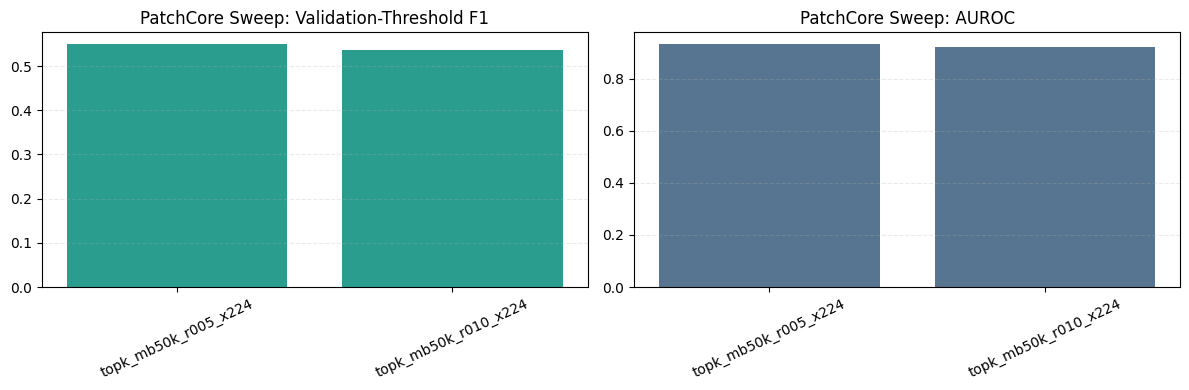

Best variant:
{
  "name": "topk_mb50k_r005_x224",
  "memory_bank_size": 600000,
  "memory_subset_images": 800,
  "patches_per_image": 784,
  "feature_dim": 1536,
  "reduction": "topk_mean",
  "topk_ratio": 0.05,
  "threshold": 0.5368722707033158,
  "precision": 0.432183908045977,
  "recall": 0.752,
  "f1": 0.548905109489051,
  "auroc": 0.9306792,
  "auprc": 0.659064076996547,
  "best_sweep_threshold": 0.5587725639343262,
  "best_sweep_precision": 0.7114427860696517,
  "best_sweep_recall": 0.572,
  "best_sweep_f1": 0.6341463414634146,
  "predicted_anomalies": 435,
  "output_dir": "C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x224\\patchcore-wideresnet50-multilayer-umap\\topk_mb50k_r005_x224"
}


In [13]:
SWEEP_RESULTS = Path(
    "C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x224\\18A2-patchcore-wideresnet50-multilayer-umap"
)
if "sweep_results_df" not in globals():
    sweep_results_df, best_row = load_existing_sweep_artifacts(SWEEP_RESULTS)

combined_results_df = sweep_results_df.copy()
combined_results_df["output_dir"] = combined_results_df["name"].map(lambda name: str((output_dir / str(name)).resolve()))

if "follow_up_results_df" in globals() and not follow_up_results_df.empty:
    follow_up_display_df = follow_up_results_df.copy()
    follow_up_display_df["output_dir"] = follow_up_display_df["name"].map(lambda name: str((output_dir / str(name)).resolve()))
    combined_results_df = (
        pd.concat([combined_results_df, follow_up_display_df], ignore_index=True)
        .sort_values(["f1", "auroc"], ascending=False)
        .reset_index(drop=True)
    )

best_row = normalize_variant_record(combined_results_df.iloc[0].to_dict(), output_dir)

display(
    combined_results_df[
        [
            "name",
            "memory_bank_size",
            "reduction",
            "topk_ratio",
            "precision",
            "recall",
            "f1",
            "auroc",
            "auprc",
            "best_sweep_f1",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(combined_results_df["name"], combined_results_df["f1"], color="#2a9d8f")
axes[0].set_title("PatchCore Sweep: Validation-Threshold F1")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")

axes[1].bar(combined_results_df["name"], combined_results_df["auroc"], color="#577590")
axes[1].set_title("PatchCore Sweep: AUROC")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()

print("Best variant:")
print(json.dumps(best_row, indent=2))


In [ ]:
variant_lookup = {str(variant["name"]): dict(variant) for variant in SWEEP_VARIANTS + FOLLOW_UP_VARIANTS}
selected_variant_name = str(best_row["name"])
if selected_variant_name not in variant_lookup:
    raise KeyError(f"Selected variant {selected_variant_name!r} not found in SWEEP_VARIANTS or FOLLOW_UP_VARIANTS.")

selected_variant = variant_lookup[selected_variant_name]
selected_output_dir = output_dir / selected_variant_name
selected_output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = selected_output_dir / SELECTED_CHECKPOINT_NAME
checkpoint_manifest_path = output_dir / "selected_checkpoint.json"

if SAVE_SELECTED_CHECKPOINT:
    if checkpoint_path.exists():
        print(f"Reusing selected checkpoint: {checkpoint_path}")
    else:
        print(f"Exporting selected checkpoint for {selected_variant_name} ...")
        checkpoint_model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=selected_variant["memory_bank_size"], reduction=selected_variant["reduction"], topk_ratio=selected_variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE).to(device)
        checkpoint_memory_subset = build_memory_subset(train_dataset, selected_variant["memory_bank_size"], checkpoint_model.patches_per_image, SEED, min_images=MIN_MEMORY_IMAGES)
        checkpoint_memory_loader = DataLoader(checkpoint_memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        checkpoint_memory_bank = collect_memory_bank(checkpoint_model, checkpoint_memory_loader, device, target_size=selected_variant["memory_bank_size"], seed=SEED)
        checkpoint_model.set_memory_bank(checkpoint_memory_bank)
        checkpoint_payload = build_selected_checkpoint_payload(checkpoint_model, metadata_path, selected_variant, float(best_row["threshold"]))
        torch.save(checkpoint_payload, checkpoint_path)
        print(f"Saved selected checkpoint: {checkpoint_path}")

    checkpoint_size_gb = checkpoint_path.stat().st_size / (1024 ** 3)
    checkpoint_manifest = {
        "best_variant": selected_variant_name,
        "checkpoint_path": str(checkpoint_path.resolve()),
        "checkpoint_name": SELECTED_CHECKPOINT_NAME,
        "approx_size_gb": round(float(checkpoint_size_gb), 3),
        "memory_bank_shape": [int(best_row["memory_bank_size"]), int(best_row["feature_dim"])],
        "note": "Checkpoint includes the fitted PatchCore memory bank, so the file is expected to be large.",
    }
    checkpoint_manifest_path.write_text(json.dumps(checkpoint_manifest, indent=2), encoding="utf-8")
    print(json.dumps(checkpoint_manifest, indent=2))
else:
    print("Skipping selected checkpoint export because SAVE_SELECTED_CHECKPOINT is False.")



selected_eval_dir = selected_output_dir / "evaluation"
selected_eval_dir.mkdir(parents=True, exist_ok=True)

if GENERATE_SELECTED_ARTIFACTS:
    print(f"Generating embedding artifacts for selected variant: {selected_variant_name}")
    selected_model = MultiLayerPatchCoreModel(
        image_size=IMAGE_SIZE,
        teacher_layers=TEACHER_LAYERS,
        memory_bank_size=selected_variant["memory_bank_size"],
        reduction=selected_variant["reduction"],
        topk_ratio=selected_variant["topk_ratio"],
        pretrained=PRETRAINED,
        freeze_backbone=FREEZE_BACKBONE,
        backbone_input_size=TEACHER_INPUT_SIZE,
        normalize_imagenet=NORMALIZE_IMAGENET,
        query_chunk_size=QUERY_CHUNK_SIZE,
        memory_chunk_size=MEMORY_CHUNK_SIZE,
    ).to(device)

    if checkpoint_path.exists():
        checkpoint_payload = torch.load(checkpoint_path, map_location="cpu")
        state_dict = checkpoint_payload.get("model_state_dict", checkpoint_payload)
        if "memory_bank" in state_dict:
            selected_model.set_memory_bank(state_dict["memory_bank"])
            selected_model.load_state_dict(state_dict, strict=False)
        else:
            selected_model.load_state_dict(state_dict, strict=False)
    else:
        selected_memory_subset = build_memory_subset(
            train_dataset,
            selected_variant["memory_bank_size"],
            selected_model.patches_per_image,
            SEED,
            min_images=MIN_MEMORY_IMAGES,
        )
        selected_memory_loader = DataLoader(selected_memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        selected_model.set_memory_bank(
            collect_memory_bank(
                selected_model,
                selected_memory_loader,
                device,
                target_size=selected_variant["memory_bank_size"],
                seed=SEED,
            )
        )

    selected_model.eval()
    val_scores_df = collect_scores(selected_model, val_loader, device)
    test_scores_df = collect_scores(selected_model, test_loader, device)
    threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
    threshold_sweep_df, best_sweep = sweep_threshold_metrics(
        test_scores_df["is_anomaly"].to_numpy(),
        test_scores_df["score"].to_numpy(),
    )

    val_scores_df.to_csv(selected_eval_dir / "val_scores.csv", index=False)
    test_scores_df.to_csv(selected_eval_dir / "test_scores.csv", index=False)
    threshold_sweep_df.to_csv(selected_eval_dir / "threshold_sweep.csv", index=False)

    selected_summary = {
        "name": selected_variant_name,
        "threshold_quantile": THRESHOLD_QUANTILE,
        "threshold": float(threshold),
        "best_threshold_sweep": {
            "threshold": float(best_sweep["threshold"]),
            "precision": float(best_sweep["precision"]),
            "recall": float(best_sweep["recall"]),
            "f1": float(best_sweep["f1"]),
            "predicted_anomalies": float(best_sweep["predicted_anomalies"]),
        },
    }
    (selected_eval_dir / "summary.json").write_text(json.dumps(selected_summary, indent=2), encoding="utf-8")

    selected_artifacts = save_patchcore_variant_artifacts(
        model=selected_model,
        variant_name=selected_variant_name,
        eval_dir=selected_eval_dir,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        val_scores_df=val_scores_df,
        test_scores_df=test_scores_df,
        threshold_sweep_df=threshold_sweep_df,
        threshold=threshold,
        best_sweep_threshold=float(best_sweep["threshold"]),
        include_umap=GENERATE_SELECTED_UMAP,
    )
    print({
        "plots_dir": str(selected_artifacts["plots_dir"]),
        "umap_points_path": str(selected_artifacts.get("umap_points_path")) if selected_artifacts.get("umap_points_path") is not None else None,
    })
else:
    print("Skipping selected artifact generation because GENERATE_SELECTED_ARTIFACTS is False.")


Reusing selected checkpoint: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224\best_model.pt
{
  "best_variant": "topk_mb50k_r005_x224",
  "checkpoint_path": "C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x224\\18A2-patchcore-wideresnet50-multilayer-umap\\topk_mb50k_r005_x224\\best_model.pt",
  "checkpoint_name": "C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x224\\18A2-patchcore-wideresnet50-multilayer-umap\\topk_mb50k_r005_x224\\best_model.pt",
  "approx_size_gb": 3.683,
  "memory_bank_shape": [
    600000,
    1536
  ],
  "note": "Checkpoint includes the fitted PatchCore memory bank, so the file is expected to be large."
}
Generating embedding artifacts for selected variant: topk_mb50k_r005_x224


Score batches:   0%|          | 0/40 [00:00<?, ?it/s]

## Selected Variant Defect Breakdown

This cell loads the selected `topk_mb50k_r010_x224` all-in-one PatchCore variant and computes its defect-type recall under the deployed validation-derived threshold.


In [ ]:
# DEFECT_BREAKDOWN_CELL
summary_path = output_dir / "patchcore_sweep_summary.json"
if "best_row" not in globals():
    if summary_path.exists():
        _, best_row = load_existing_sweep_artifacts(output_dir)
    else:
        raise FileNotFoundError(f"Sweep summary not found: {summary_path}. No retraining needed, but rerun the sweep summary cell first.")
else:
    best_row = normalize_variant_record(best_row, output_dir)

required_globals = ["output_dir", "test_dataset"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "No retraining needed. Rerun the notebook setup/data cells so these objects exist: "
        + ", ".join(missing_globals)
    )

best_variant_name = str(best_row["name"])
best_threshold = float(best_row["threshold"])
variant_output_dir = Path(best_row["output_dir"])
best_scores_path = variant_output_dir / "test_scores.csv"
if not best_scores_path.exists():
    raise FileNotFoundError(f"Test scores not found for best variant: {best_scores_path}")

best_scores_df = pd.read_csv(best_scores_path).reset_index(drop=True)
analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
if len(best_scores_df) != len(analysis_df):
    raise ValueError(f"Length mismatch: scores={len(best_scores_df)} metadata={len(analysis_df)}")
analysis_df["score"] = best_scores_df["score"]
analysis_df["predicted_anomaly"] = (analysis_df["score"] >= best_threshold).astype(int)

defect_breakdown_df = (
    analysis_df.loc[analysis_df["is_anomaly"] == 1]
    .groupby("defect_type")
    .agg(
        count=("defect_type", "size"),
        detected=("predicted_anomaly", "sum"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
    )
    .reset_index()
)
defect_breakdown_df["detected"] = defect_breakdown_df["detected"].astype(int)
defect_breakdown_df["missed"] = defect_breakdown_df["count"] - defect_breakdown_df["detected"]
defect_breakdown_df["recall"] = defect_breakdown_df["detected"] / defect_breakdown_df["count"]
defect_breakdown_df = defect_breakdown_df.sort_values(["recall", "count", "defect_type"], ascending=[True, False, True]).reset_index(drop=True)

display(pd.Series(best_row))
display(defect_breakdown_df)
output_path = variant_output_dir / "selected_defect_breakdown.csv"
defect_breakdown_df.to_csv(output_path, index=False)
print(f"Saved defect breakdown to {output_path}")


c:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


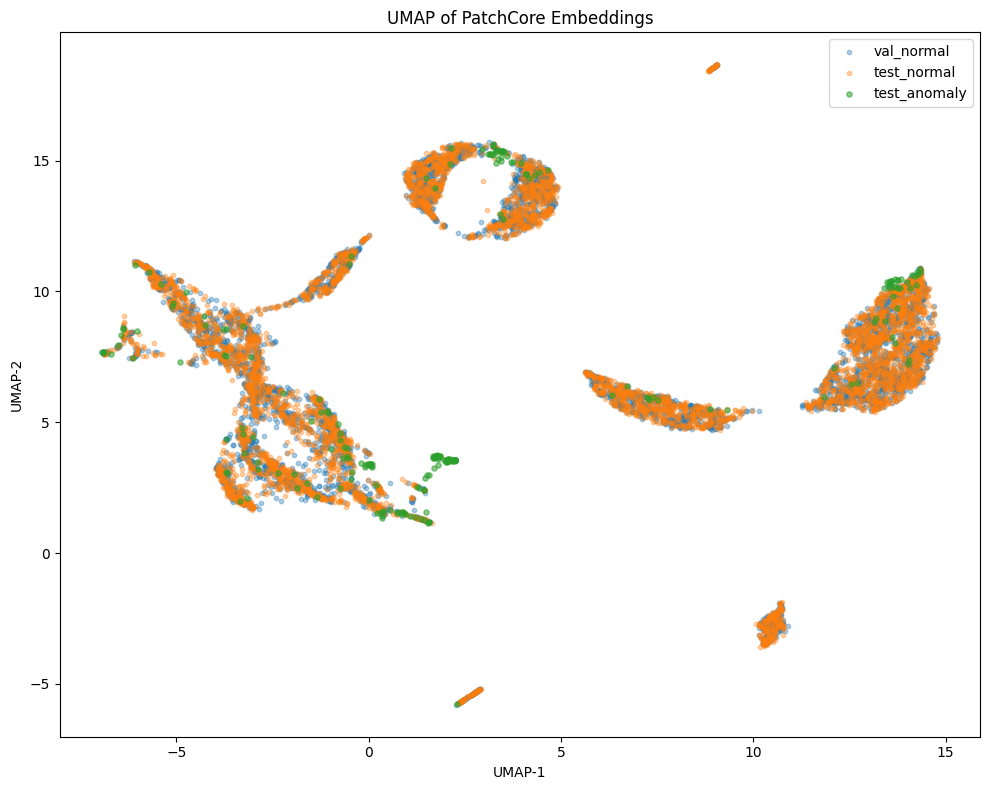

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap

val_embeddings = np.load(r"C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224\val_embeddings.npy")
test_embeddings = np.load(r"C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224\test_embeddings.npy")

val_labels = np.load(r"C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224\val_labels.npy")
test_labels = np.load(r"C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224\test_labels.npy")

X = np.concatenate([val_embeddings, test_embeddings], axis=0)
split_label = (
    ["val_normal"] * len(val_embeddings)
    + ["test_anomaly" if y == 1 else "test_normal" for y in test_labels]
)
is_anomaly = np.concatenate([
    np.zeros(len(val_embeddings), dtype=int),
    test_labels.astype(int)
])

pca_dim = min(50, X.shape[0], X.shape[1])
X_pca = PCA(n_components=pca_dim, random_state=42).fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
)
X_umap = reducer.fit_transform(X_pca)

umap_df = pd.DataFrame({
    "umap_1": X_umap[:, 0],
    "umap_2": X_umap[:, 1],
    "split_label": split_label,
    "is_anomaly": is_anomaly,
})

plt.figure(figsize=(10, 8))
for name, alpha, size in [
    ("val_normal", 0.35, 10),
    ("test_normal", 0.35, 10),
    ("test_anomaly", 0.55, 14),
]:
    g = umap_df[umap_df["split_label"] == name]
    plt.scatter(g["umap_1"], g["umap_2"], s=size, alpha=alpha, label=name)

plt.title("UMAP of PatchCore Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# === UPDATE PATH ===
base_dir = r"C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224"

test_embeddings = np.load(base_dir + r"\test_embeddings.npy")
test_labels = np.load(base_dir + r"\test_labels.npy")   # 0 = normal, 1 = anomaly

print("Embeddings shape:", test_embeddings.shape)
print("Anomaly count:", (test_labels == 1).sum())

Embeddings shape: (5250, 1536)
Anomaly count: 250


In [7]:
k = 15  # neighborhood size

nbrs = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
nbrs.fit(test_embeddings)

distances, indices = nbrs.kneighbors(test_embeddings)

# remove self
neighbor_idx = indices[:, 1:]
neighbor_labels = test_labels[neighbor_idx]

# ratio of normal neighbors
normal_ratio = 1.0 - neighbor_labels.mean(axis=1)

# define embedded anomalies
threshold = 0.8

embedded_mask = (test_labels == 1) & (normal_ratio >= threshold)

total_anomalies = (test_labels == 1).sum()
embedded_count = embedded_mask.sum()
fraction = embedded_count / total_anomalies

print(f"Total anomalies: {total_anomalies}")
print(f"Embedded anomalies (>= {threshold:.0%} normal neighbors): {embedded_count}")
print(f"Embedded anomaly fraction: {fraction:.3f}")

Total anomalies: 250
Embedded anomalies (>= 80% normal neighbors): 115
Embedded anomaly fraction: 0.460


In [8]:
scores = np.load(base_dir + r"\test_scores.npy")

print("All anomaly scores:")
print(scores[test_labels == 1].mean())

print("Embedded anomaly scores:")
print(scores[embedded_mask].mean())

All anomaly scores:
0.56865263
Embedded anomaly scores:
0.54674774


In [11]:
from pathlib import Path

CHECKPOINT_PATH = Path(r"C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224\best_model.pt")

# use the full metadata csv here
FULL_METADATA_CSV = r"data/processed/x64/wm811k/metadata_50k_5pct_holdout70k_3p5k.csv"

FULL_OUTPUT_DIR = CHECKPOINT_PATH.parent / "full_test_embeddings"
FULL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(CHECKPOINT_PATH)
print(FULL_OUTPUT_DIR)

C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224\best_model.pt
C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\18A2-patchcore-wideresnet50-multilayer-umap\topk_mb50k_r005_x224\full_test_embeddings


In [13]:
import torch
import numpy as np
from torch.utils.data import DataLoader

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")

config = checkpoint.get("config", {})
print(config)

{'run': {'output_dir': '/root/artifacts/x224/patchcore-wideresnet50-multilayer-umap', 'seed': 42}, 'training': {'device': 'auto'}, 'data': {'metadata_csv': '/root/artifacts/x224/patchcore-wideresnet50-multilayer-umap/processed/metadata_50k_5pct.csv', 'image_size': 224, 'batch_size': 128, 'num_workers': 0}, 'model': {'type': 'patchcore', 'backbone_type': 'wideresnet50_2', 'teacher_layers': ['layer2', 'layer3'], 'pretrained': True, 'freeze_backbone': True, 'backbone_input_size': 224, 'normalize_imagenet': True, 'query_chunk_size': 1024, 'memory_chunk_size': 4096, 'memory_bank_size': 600000, 'reduction': 'topk_mean', 'topk_ratio': 0.05}, 'scoring': {'threshold_quantile': 0.95, 'threshold': 0.5368722707033158}}


In [19]:
data_config = config.get("data", {})
model_config = config.get("model", {})

# override only the metadata csv so you use the bigger test set
data_config["metadata_csv"] = FULL_METADATA_CSV

image_size = int(data_config.get("image_size", 224))
batch_size = int(data_config.get("batch_size", 64))
num_workers = int(data_config.get("num_workers", 4))

model = MultiLayerPatchCoreModel(
    image_size=image_size,
    teacher_layers=model_config.get("teacher_layers", ["layer2", "layer3"]),
    memory_bank_size=int(model_config.get("memory_bank_size", 50000)),
    reduction=str(model_config.get("reduction", "topk_mean")),
    topk_ratio=float(model_config.get("topk_ratio", 0.05)),
    pretrained=bool(model_config.get("pretrained", True)),
    freeze_backbone=bool(model_config.get("freeze_backbone", True)),
    backbone_input_size=int(model_config.get("backbone_input_size", 224)),
    normalize_imagenet=bool(model_config.get("normalize_imagenet", True)),
    query_chunk_size=int(model_config.get("query_chunk_size", 2048)),
    memory_chunk_size=int(model_config.get("memory_chunk_size", 8192)),
)

state_dict = checkpoint["model_state_dict"]

if "memory_bank" in state_dict:
    model.set_memory_bank(state_dict["memory_bank"])
    model.load_state_dict(state_dict, strict=False)
else:
    model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print("Model loaded.")

Model loaded.


In [21]:
state_dict = checkpoint["model_state_dict"]

if "memory_bank" in state_dict:
    model.set_memory_bank(state_dict["memory_bank"])
    model.load_state_dict(state_dict, strict=False)
else:
    model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [30]:
FULL_METADATA_CSV = Path(r"C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\data\processed\x64\wm811k\metadata_50k_5pct_holdout70k_3p5k.csv")

test_dataset = WaferArrayDataset(
    metadata_csv=FULL_METADATA_CSV,
    split="test",
)

test_dataset.metadata["array_path"] = test_dataset.metadata["array_path"].apply(
    lambda p: str((PROJECT_ROOT / p).resolve()) if not Path(p).is_absolute() else p
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

print("Test dataset size:", len(test_dataset))

Test dataset size: 73500


In [31]:
def get_patchcore_embeddings(model, inputs):
    if hasattr(model, "patch_embeddings") and callable(model.patch_embeddings):
        out = model.patch_embeddings(inputs)
    elif hasattr(model, "feature_map") and callable(model.feature_map):
        out = model.feature_map(inputs)
    else:
        raise AttributeError("PatchCore model missing embedding method")

    if isinstance(out, (tuple, list)):
        for item in out:
            if hasattr(item, "shape"):
                out = item
                break

    if out.dim() == 3:
        out = out.mean(dim=1)
    elif out.dim() > 3:
        out = out.view(out.size(0), -1)

    return out

In [ ]:
test_embeddings_list = []
test_labels_list = []

with torch.inference_mode():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        emb = get_patchcore_embeddings(model, inputs)

        test_embeddings_list.append(emb.cpu().numpy())
        test_labels_list.append(labels.cpu().numpy())

test_embeddings = np.concatenate(test_embeddings_list, axis=0)
test_labels = np.concatenate(test_labels_list, axis=0)

print("Embeddings shape:", test_embeddings.shape)
print("Labels shape:", test_labels.shape)

unique, counts = np.unique(test_labels, return_counts=True)
print(dict(zip(unique, counts)))

In [ ]:
np.save(FULL_OUTPUT_DIR / "test_embeddings_full.npy", test_embeddings)
np.save(FULL_OUTPUT_DIR / "test_labels_full.npy", test_labels)

print("Saved to:", FULL_OUTPUT_DIR)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap

# optional subsampling for faster plotting
rng = np.random.default_rng(42)

normal_idx = np.where(test_labels == 0)[0]
anomaly_idx = np.where(test_labels == 1)[0]

max_normal = 12000
max_anomaly = 3500

if len(normal_idx) > max_normal:
    normal_idx = rng.choice(normal_idx, max_normal, replace=False)

if len(anomaly_idx) > max_anomaly:
    anomaly_idx = rng.choice(anomaly_idx, max_anomaly, replace=False)

keep_idx = np.concatenate([normal_idx, anomaly_idx])

X = test_embeddings[keep_idx]
y = test_labels[keep_idx]

pca_dim = min(50, X.shape[0], X.shape[1])
X_pca = PCA(n_components=pca_dim, random_state=42).fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
)

X_umap = reducer.fit_transform(X_pca)

umap_df = pd.DataFrame({
    "umap_1": X_umap[:, 0],
    "umap_2": X_umap[:, 1],
    "is_anomaly": y,
})

plt.figure(figsize=(10, 8))

g0 = umap_df[umap_df["is_anomaly"] == 0]
g1 = umap_df[umap_df["is_anomaly"] == 1]

plt.scatter(g0["umap_1"], g0["umap_2"], s=10, alpha=0.20, label="test_normal")
plt.scatter(g1["umap_1"], g1["umap_2"], s=14, alpha=0.45, label="test_anomaly")

plt.title("UMAP of PatchCore Embeddings (Full Test Set)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()

umap_df.to_csv(FULL_OUTPUT_DIR / "embedding_umap_points_full.csv", index=False)